# PyVBMC Example 8: Fitting a PyMC model

In this notebook, we fit a PyMC model with PyVBMC, convert the variational posterior back to PyMC's named variables, and use PyMC and ArviZ for posterior analysis and prediction. We also run a short NUTS fit as a reference for the posterior marginals.

This notebook is Part 8 of a series of notebooks presenting example uses of VBMC with the PyVBMC package. The adapter requires Python 3.12 or newer and the optional `pymc` dependency group, installed with `pip install "pyvbmc[pymc]"`. The example uses fixed seeds so that its simulated data, PyVBMC run, exported samples, posterior predictive draws, and NUTS comparison are reproducible.

In [1]:
import arviz as az
import numpy as np
import pymc as pm

from pyvbmc import PyMCTarget, VBMC

SEED = 7

g++ not available, if using conda: `conda install gxx`


## 1. A regression model in PyMC

We simulate a small linear regression with an intercept, a slope, and an unknown observation scale. Named coordinates keep the two entries of `beta` identifiable throughout the PyMC workflow. The positive `sigma` parameter uses PyMC's default logarithmic value transform, and `mu` is a deterministic vector used by the likelihood.

In [2]:
rng = np.random.default_rng(SEED)
n_observations = 30
predictor = np.linspace(-1.0, 1.0, n_observations)
design = np.column_stack([np.ones(n_observations), predictor])
beta_true = np.array([0.5, 1.0])
sigma_true = 0.7
observed = design @ beta_true + rng.normal(
    0.0, sigma_true, size=n_observations
)

coords = {
    "coef": ["intercept", "slope"],
    "observation": np.arange(n_observations),
}
with pm.Model(coords=coords) as model:
    beta = pm.Normal("beta", mu=0.0, sigma=5.0, dims="coef")
    sigma = pm.HalfNormal("sigma", sigma=2.0)
    mu = pm.Deterministic("mu", design @ beta, dims="observation")
    pm.Normal(
        "y",
        mu=mu,
        sigma=sigma,
        observed=observed,
        dims="observation",
    )

## 2. From the model to a PyVBMC target

`PyMCTarget` snapshots the model data, checks that its free variables have supported continuous geometry, and prepares a finite starting point and plausible box. Its setup evaluates the same joint density that PyVBMC will see. Those finite evaluations are retained for reuse, while the setup work is recorded as a function-equivalent cost.

The printed table describes both coordinate systems. The two unbounded `beta` coordinates stay in model space. The one-sided positive `sigma` keeps PyMC's `sigma_log__` transform, so PyVBMC works on an unbounded coordinate and its log joint includes the transform Jacobian. The default plausible box comes from local curvature, with prior-draw fallbacks when curvature is not usable.

In [3]:
target = PyMCTarget(model, seed=SEED)
print(target)

variable | shape | VBMC coordinates | kept transform | hard bounds | plausible bounds | start
beta | (2,) | beta[intercept], beta[slope] | - | [[-inf -inf], [inf inf]] | [[-0.09952025  0.24172931], [0.52304277 1.28427527]] | [0.21176126 0.76300229]
sigma | () | sigma_log__ | LogTransform | [[-inf], [inf]] | [[-0.95859605], [-0.1711322]] | [-0.56486412]


## 3. Run PyVBMC

Passing the target directly resolves its starting point, hard and plausible bounds, setup observations, and setup cost. `max_fun_evals` is the total function-equivalent allowance: the target's setup cost is charged once, and the remainder is available for fresh evaluations during optimization. Reused setup observations do not increment the fresh-call counter, and PyVBMC still constructs its ordinary initial design.

In [4]:
total_budget = 150
vbmc = VBMC(
    target,
    options={"max_fun_evals": total_budget, "display": "off"},
    seed=SEED,
)
vp, results = vbmc.optimize()

budget = results["evaluation_budget"]
print(f"Convergence status: {results['convergence_status']}")
print(
    "Function-equivalent budget: "
    f"{budget['used']} used of {budget['limit']} "
    f"({budget['initialization']} setup + {budget['new_calls']} fresh)"
)
print(
    "Reused setup observations: "
    f"{results.get('precomputed_observations', 0)}"
)

Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -34.907 +/-0.001.


Convergence status: probable
Function-equivalent budget: 81 used of 150 (12 setup + 69 fresh)
Reused setup observations: 9


## 4. Back to PyMC

The variational posterior lives internally in a flat PyVBMC coordinate system. `target.to_arviz` draws from it and returns an ArviZ `DataTree` whose posterior variables have the original PyMC names, shapes, dimensions, and coordinates. The summary below asks only for marginal statistics: unlike MCMC draws, independent draws from a fitted variational distribution do not have chain convergence diagnostics such as $\hat R$.

In [5]:
posterior_data = target.to_arviz(vp, n_samples=1000)
vbmc_summary = az.summary(
    posterior_data,
    var_names=["beta", "sigma"],
    kind="stats",
    round_to=3,
)
vbmc_summary

,mean,sd,eti89_lb,eti89_ub
beta[intercept],0.209,0.115,0.007,0.386
beta[slope],0.769,0.184,0.482,1.049
sigma,0.608,0.084,0.490,0.758


PyMC can compute deterministics from these named posterior variables. Here it adds the full regression mean `mu` to the same `DataTree` for every exported draw. `extend_dataset=True` preserves `beta` and `sigma`; keeping those free variables is essential because posterior predictive sampling conditions on them by name.

In [6]:
posterior_data = pm.compute_deterministics(
    posterior_data,
    model=target.model,
    var_names=["mu"],
    extend_dataset=True,
    progressbar=False,
)
assert {"beta", "sigma", "mu"} <= set(posterior_data.posterior.data_vars)
posterior_data.posterior["mu"]

<xarray.DataArray 'mu' (chain: 1, draw: 1000, observation: 30)> Size: 240kB
array([[[-0.2381438 , -0.20654873, -0.17495366, ...,  0.61492309,
          0.64651816,  0.67811323],
        [-0.6171671 , -0.56066788, -0.50416865, ...,  0.90831207,
          0.9648113 ,  1.02131053],
        [-0.48378436, -0.44005118, -0.39631801, ...,  0.69701137,
          0.74074455,  0.78447772],
        ...,
        [-0.20088343, -0.16966971, -0.13845599, ...,  0.641887  ,
          0.67310072,  0.70431444],
        [-1.24292346, -1.1571058 , -1.07128815, ...,  1.07415318,
          1.15997083,  1.24578848],
        [-0.66381389, -0.60349951, -0.54318514, ...,  0.96467426,
          1.02498863,  1.08530301]]], shape=(1, 1000, 30))
Coordinates:
  * chain        (chain) int64 8B 0
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * observation  (observation) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29

The original model retained by `target.model` is also the prediction model. We draw replicated observations and use ArviZ 1.x's interval plot to compare their posterior predictive intervals with the observed data.

Sampling: [y]


Sampling: [y]


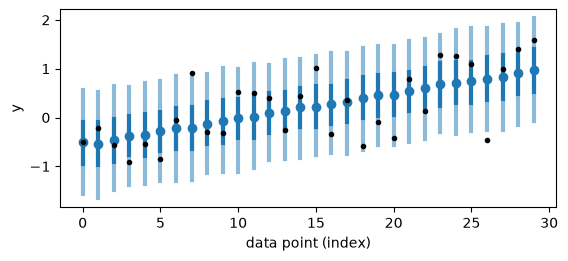

In [7]:
posterior_predictive = pm.sample_posterior_predictive(
    posterior_data,
    model=target.model,
    var_names=["y"],
    random_seed=SEED,
    progressbar=False,
)
az.plot_ppc_interval(
    posterior_predictive,
    var_names=["y"],
    point_estimate="mean",
    ci_probs=(0.5, 0.9),
)

## 5. Comparison with PyMC's NUTS sampler

For this small, smooth model, NUTS is a natural reference. We run two short seeded chains on one core, then compare the marginal intervals from NUTS with those from PyVBMC. This is a posterior comparison, rather than a comparison with the setup probe or with a fixed parameter truth: finite simulated data move the posterior away from the values used to generate them.

In [8]:
with model:
    nuts_data = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=SEED,
        progressbar=False,
    )

az.summary(
    nuts_data,
    var_names=["beta", "sigma"],
    kind="all",
    round_to=3,
)

Initializing NUTS using jitter+adapt_diag...


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


Sequential sampling (2 chains in 1 job)


NUTS: [beta, sigma]


...

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[intercept],0.209,0.109,0.037,0.385,835.013,549.313,1.005,0.004,0.004
beta[slope],0.759,0.196,0.450,1.075,722.737,590.703,1.000,0.007,0.007
sigma,0.606,0.086,0.484,0.746,775.501,574.046,1.002,0.003,0.004


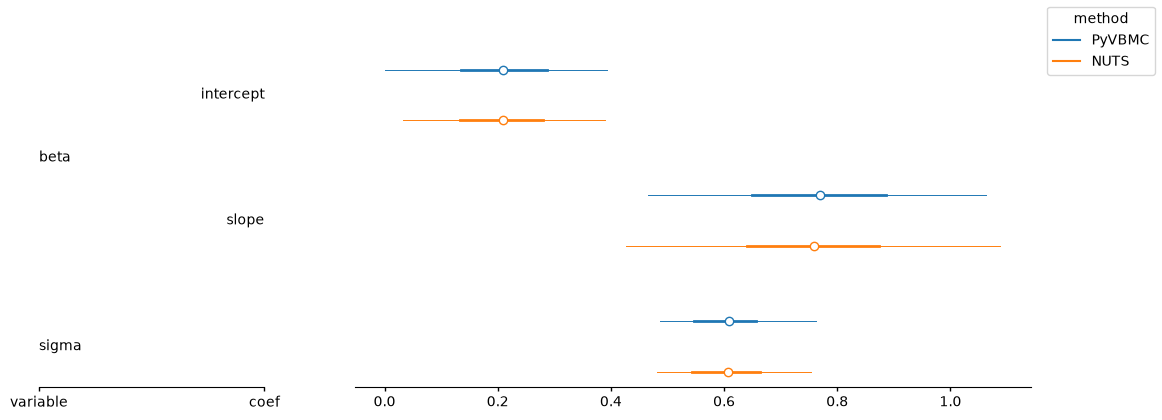

In [9]:
# Use a common sample axis for the independent draws and NUTS chains.
forest_data = {
    label: az.extract(data, var_names=["beta", "sigma"]).reset_index(
        "sample", drop=True
    )
    for label, data in {"PyVBMC": posterior_data, "NUTS": nuts_data}.items()
}
forest = az.plot_forest(
    forest_data,
    var_names=["beta", "sigma"],
    sample_dims="sample",
    combined=True,
    point_estimate="mean",
    ci_probs=(0.5, 0.9),
)
forest.add_legend("model", title="method");

The paired intervals should substantially overlap for the intercept, slope, and observation scale. Small differences are expected: PyVBMC returns an optimized variational approximation from a limited evaluation budget, whereas NUTS estimates the posterior with correlated Markov-chain draws.

## 6. Conclusions

- Construct `PyMCTarget(model)` once and pass it directly to `VBMC`. Setup observations are reused, and setup work is charged once within the total function-equivalent budget.
- The adapter supports continuous float64 free variables whose coordinates are unbounded or bounded on both sides. One-sided variables keep a dimension-preserving PyMC transform and its Jacobian. It rejects discrete variables, transforms that change dimension, and unsupported or mixed support geometries.
- `target.to_arviz` restores model variable names, shapes, dimensions, and coordinates. The resulting `DataTree` works with ArviZ summaries and plots and with PyMC deterministics and posterior predictive sampling.
- PyVBMC is most useful when each target evaluation is expensive, the evaluation budget is limited, or a model-evidence estimate is important. For a cheap differentiable PyMC model where many gradient evaluations are affordable, PyMC's own NUTS sampler is usually the better default and provides standard MCMC diagnostics.

`PyMCTarget` freezes inference inputs when it is constructed. Use `target.model` for prediction, and construct a new target if the inference data or model structure changes.

## Acknowledgments

Work on the PyVBMC package was funded by the [Finnish Center for Artificial Intelligence FCAI](https://fcai.fi/).